In [ ]:
! pip install pandas matplotlib scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler     #scale numbers between 0 and 1 
from sklearn.tree import DecisionTreeClassifier, plot_tree  #train and visualize decision tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [111]:
df = pd.read_csv('student_study_habits.csv')
print(df.columns)

Index(['Study_hours_per_week', 'Sleep_hours_per_day', 'Attendance_percentage',
       'Assignments_completed', 'Final_grade', 'participation_level_Low',
       'participation_level_Medium', 'internet_access_Yes',
       'parental_education_High School', 'parental_education_Master's',
       'parental_education_PhD', 'Extra-Classes', 'part_time_job_Yes'],
      dtype='object')


In [112]:
#column names bata extra space hataucha
df.columns = df.columns.str.strip()

In [113]:
#Pass and Fail binary target create garcha
df['Pass_Fail'] = df['Final_grade'].apply(lambda x: 1 if x >=50 else 0)

In [114]:
df = df.drop(columns=['Final_grade', 'parental_education_High School'])

In [115]:
X = df.drop(columns=['Pass_Fail']) #Model le herne all features hercha except pass/fail, removes the answer so that model can't cheat
y = df['Pass_Fail'] #target/output Model le predict garne

In [116]:
df.head()

,Study_hours_per_week,Sleep_hours_per_day,Attendance_percentage,Assignments_completed,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_Master's,parental_education_PhD,Extra-Classes,part_time_job_Yes,Pass_Fail
0,0.527230,0.685236,0.993245,0.222222,0,1,1,0,0,1,0,1
1,0.421400,0.881883,0.883478,0.555556,0,1,1,0,0,0,0,1
2,0.552393,0.220286,0.683469,1.000000,0,1,1,0,0,1,0,1
3,0.698283,0.612594,0.520094,0.222222,1,0,1,0,0,1,0,1
4,0.405419,0.369871,0.831127,0.333333,0,1,1,0,0,1,0,1


In [117]:
# 80% train and 20% test- accuracy check garna ra model le sikna
X_train, X_test, y_train, y_test = train_test_split ( X, y, test_size=0.2, random_state=42 )

In [118]:
# SCALE FEATURES (0-1)
scaler = MinMaxScaler()        #scaling le model numeric data uniform banaucha
X_train_scaled = scaler.fit_transform(X_train)  #all features lai 0-1 ko bich ma scale garne
X_test_scaled = scaler.transform(X_test)         #helps logistic regression

In [119]:
depths = [2, 3, 5]    #different depths try garna
dt_models = {}
print("Decision Tree Accuracies for different depths:\n")

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    y_pred = dt.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)   #model ma kasto accuracy cha bhanera herna
    dt_models[d] = dt                   # stores  model for later use
    print(f"Max Depth={d}: Accuracy = {acc:.2f}")

Decision Tree Accuracies for different depths:

Max Depth=2: Accuracy = 0.95
Max Depth=3: Accuracy = 0.95
Max Depth=5: Accuracy = 0.97


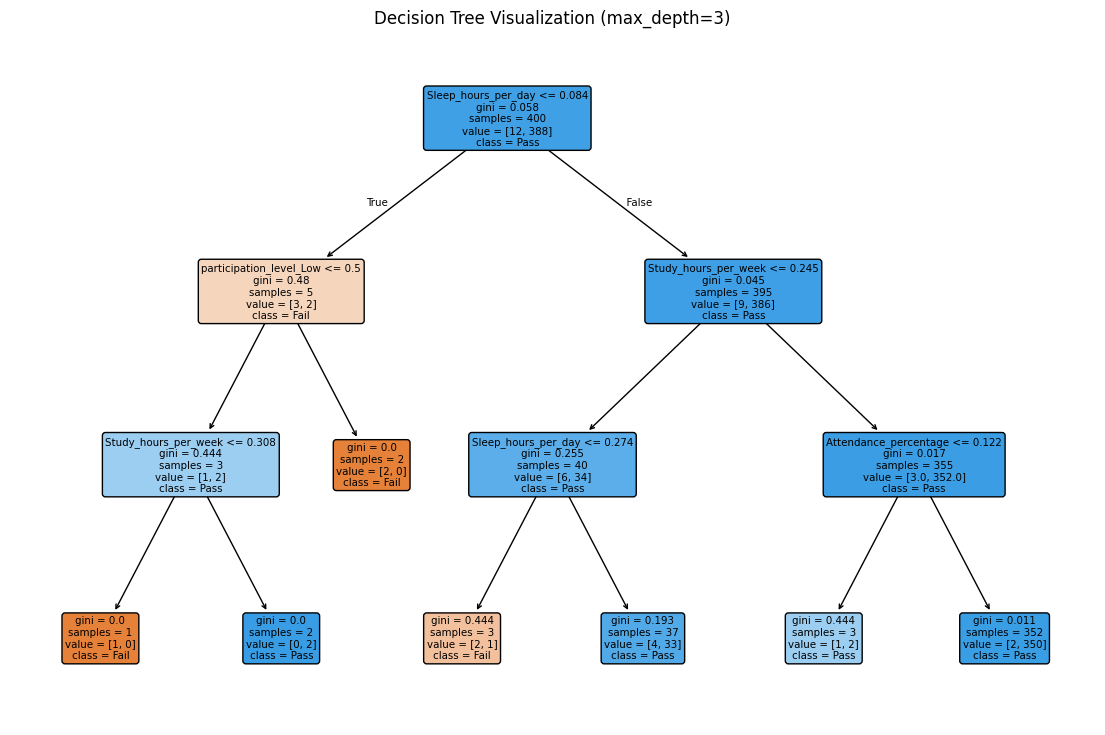

In [123]:
# Decision tree checks study hours first, then attendance, extra classes and predicts pass/fail
plt.figure(figsize=(14,9)) # width, height
plot_tree(dt_models[3],      #visualize decision tree with max_depth=3
          feature_names=X.columns,
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

In [121]:
## Example: studies 9 hours/week, 85% attendance, sleeps 7 hours/day, takes Extra Classes
new_student_raw = pd.DataFrame({
    'Study_hours_per_week':[9],
    'Sleep_hours_per_day':[7],
    'Attendance_percentage':[85],
    'Assignments_completed':[10],
    'participation_level_Low':[0],
    'participation_level_Medium':[1],
    'internet_access_Yes':[1],
    "parental_education_Master's":[1],
    'parental_education_PhD':[0],
    'Extra-Classes':[1],
    'part_time_job_Yes':[1]
})

# Training ma jun scaler use gareko thyo, tyo nai use garne natra models confuse
new_student_scaled = scaler.transform(new_student_raw)

# Predict using max_depth=3 model
prediction = dt_models[3].predict(new_student_scaled)
print("\nPrediction for new student:", "Pass" if prediction[0]==1 else "Fail")


Prediction for new student: Pass


In [126]:
lr = LogisticRegression(random_state=42)   #create logistic regression model

In [127]:
lr.fit(X_train_scaled, y_train)               #train gareko

LogisticRegression(random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)     #predict garna
accuracy_lr = accuracy_score(y_test, y_pred_lr)  #measures accuracy
print(f"\nLogistic Regression Accuracy: {accuracy_lr:.2f}")


Logistic Regression Accuracy: 0.96
